<a href="https://colab.research.google.com/github/thiagopereiramagalhaes/Analise_de_Letras_de_Musicas-Exploracao_Textual_Busca_por_Similaridade_e_Clusterizacao/blob/main/An%C3%A1lise_de_Letras_de_M%C3%BAsicas_Explora%C3%A7%C3%A3o_Textual%2C_Busca_por_Similaridade_e_Clusteriza%C3%A7%C3%A3o_com_TF_IDF_e_UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Letras de Músicas: Exploração Textual, Busca por Similaridade e Clusterização com TF-IDF e UMAP

# Explorando Texto e Nomes de Músicas  - Parte 1 🎵🔍

Objetivo: "A dinâmica dessa fase 1 do exercício é justamente realizar a exploração da base e construir algumas funcionalidades simples (como o buscador de palavras no texto da letra da música)"

Base de dados: https://raw.githubusercontent.com/devjaynemorais/modelos_descritivos_curso/main/Aula%2001/dados/dataset_lyrics.csv

## Limpeza dos dados

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/devjaynemorais/modelos_descritivos_curso/main/Aula%2001/dados/dataset_lyrics.csv')

In [ ]:
df.head()

,cantorId,cantorNome,musicaNome,letra
0,0,10000-maniacs,More Than This,I could feel at the time. There was no way of ...
1,0,10000-maniacs,Because The Night,"Take me now, baby, here as I am. Hold me close..."
2,0,10000-maniacs,These Are Days,These are. These are days you'll remember. Nev...
3,0,10000-maniacs,A Campfire Song,"A lie to say, ""O my mountain has coal veins an..."
4,0,10000-maniacs,Everyday Is Like Sunday,Trudging slowly over wet sand. Back to the ben...


### Removendo qualquer registro que possua pelo menos uma coluna nula

In [ ]:
df[df.isnull().any(axis=1)]

,cantorId,cantorNome,musicaNome,letra
4943,56,bad-religion,Whisper In Time (traduçâo),NaN
4966,57,badfinger,Baby Blue (traduzida),NaN
4977,57,badfinger,Carry On Till Tomorrow (traduzida),NaN
4986,57,badfinger,Day After Day (traduzida),NaN
12308,141,catch-side,Deixar Partir,NaN
26195,289,good-charlotte,S.O.S. (traducción),NaN
31193,343,joan-jett-the-blackhearts,Dirty Deeds (traduçâo),NaN
32107,354,jonas-brothers,We Rock (Camp Rock) (traducción),NaN
32278,354,jonas-brothers,We Rock (Camp Rock) (traducción),NaN
47053,502,oficina-g3,Espelhos Mágicos,NaN


In [ ]:
df.drop(df[df.isnull().any(axis=1)].index, inplace=True)

In [ ]:
df[df.isnull().any(axis=1)]

,cantorId,cantorNome,musicaNome,letra


### Removendo todos os registros duplicados

In [ ]:
grouped_df = df.groupby(['cantorNome', 'musicaNome', 'letra']).count()
duplicated_records = grouped_df[grouped_df['cantorId'] > 1]
print(duplicated_records)

                                                                                                           cantorId
cantorNome      musicaNome                             letra                                                       
10000-maniacs   A Campfire Song                        A lie to say, "O my mountain has coal veins and...         2
                A Room For Everything                  You were looking away from me, western skies ca...         2
                Across The Fields                      Well they left then in the morning, a hundred p...         2
                All That Never Happens                 She walks alone on the brick lane,. the breeze ...         2
                Anthem For Doomed Youth                For whom do the bells toll. When sentenced to d...         2
...                                                                                                             ...
the-arcade-fire Reflektor                              Trapped in a pris

In [ ]:
df.drop_duplicates(inplace=True)

## Análise de palavras e artistas que mais se repetem

### Artistas que mais se repetem

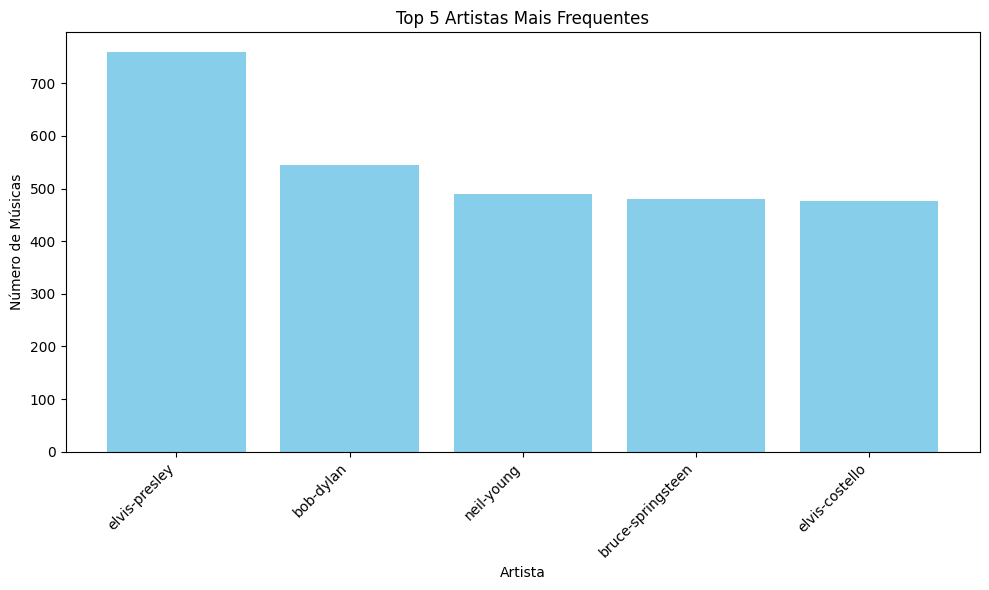

In [ ]:
import matplotlib.pyplot as plt

top_5_artists = df.cantorNome.value_counts().head(5)

plt.figure(figsize=(10, 6))
plt.bar(top_5_artists.index, top_5_artists.values, color='skyblue')
plt.xlabel('Artista')
plt.ylabel('Número de Músicas')
plt.title('Top 5 Artistas Mais Frequentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Palavras que mais se repetem

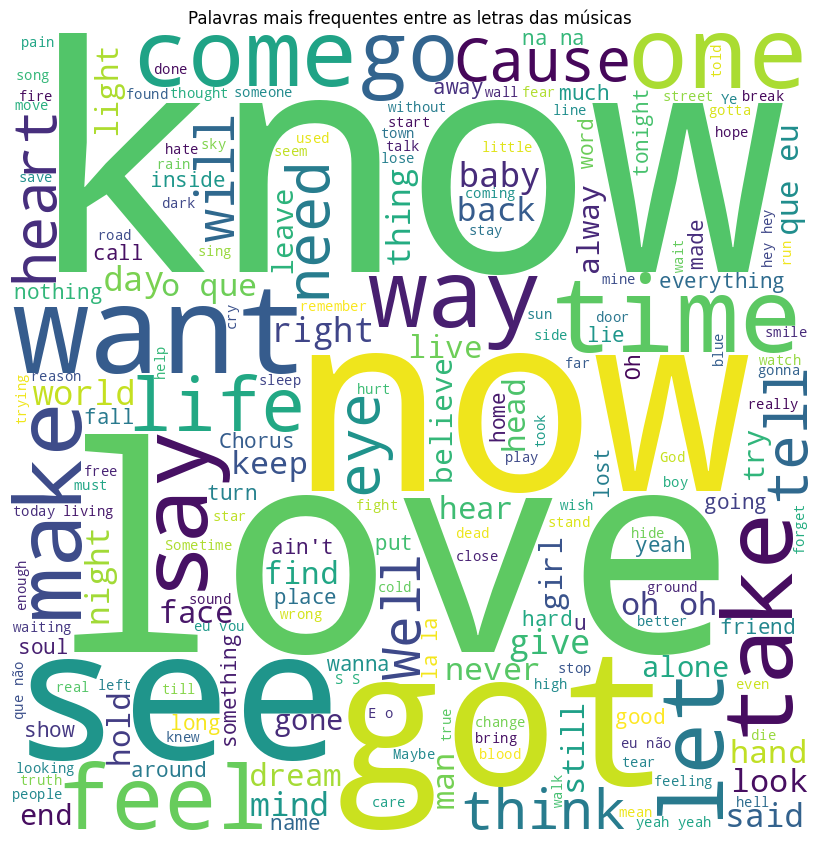

In [ ]:
from wordcloud import WordCloud

all_lyrics_text = df.letra.str.cat(sep=' ')

wordcloud = WordCloud(width = 800, height = 800, background_color ='white', min_font_size = 10).generate(all_lyrics_text)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.title('Palavras mais frequentes entre as letras das músicas')
plt.show()

### Interpretação:

A nuvem de palavras revela que termos como 'know', 'love', 'don't', 'time' e 'now' são extremamente comuns no dataset. Isso é esperado em letras de música, que frequentemente focam em sentimentos, relacionamentos e ações imediatas. A predominância de palavras curtas e verbos de estado indica uma linguagem direta e emocional.

## Qual música repete mais o termo "know"?

In [ ]:
import re

# Usamos \b para cercar a palavra, garantindo que seja a palavra exata
# O r antes das aspas indica uma 'raw string' (necessário para o \b)
regex_pattern = rf'\bknow\b'

# Agora usamos .str.count com o padrão de Regex
df['know_count'] = df['letra'].str.lower().str.count(regex_pattern)

# O restante do código permanece igual
top_5_know_songs = df.sort_values(by='know_count', ascending=False).head(5)
top_5_know_songs[['musicaNome', 'cantorNome', 'know_count']]

,musicaNome,cantorNome,know_count
40066,Don't Wanna Know (Ft. Kendrick Lamar) (Chris T...,maroon-5,45
40020,Don't Wanna Know (Feat. Kendrick Lamar),maroon-5,45
1512,Lover Alot,aerosmith,45
6456,Ain't No Sunshine,ben-harper,41
40067,Don't Wanna Know (TEEZ Remix),maroon-5,40


### Interpretação:

A análise mostra que a música 'Lover Alot' do Aerosmith e variações de 'Don't Wanna Know' do Maroon 5 são as que mais repetem o termo 'know' (45 vezes). Isso geralmente acontece em músicas com refrões repetitivos ou 'hooks' marcantes, onde a palavra chave é utilizada para reforçar a melodia e a mensagem central da canção.

## O termo "know" está mais presente nas músicas de quais artistas?

In [ ]:
know_counts_by_artist = df.groupby('cantorNome')['know_count'].sum()
know_counts_by_artist.head(5)

,know_count
cantorNome,
10000-maniacs,82
12-stones,133
3-doors-down,165
311,297
4-non-blondes,22


### Interpretação:

Ao agrupar por artista, observamos que artistas com carreiras longas e volumosas (como Elvis Presley e Bob Dylan, vistos no Top 5 de músicas) tendem a acumular um maior número total de ocorrências de palavras comuns. No entanto, artistas pop modernos como Maroon 5 também se destacam devido à alta repetição interna em suas composições específicas.

# Buscador: Calculando Distância entre Texto e Nomes de Músicas - Parte 2

In [ ]:
!pip install fuzzywuzzy python-Levenshtein

In [ ]:
from fuzzywuzzy import process

In [ ]:
def buscar_musica(termo_busca, top_n=5):
  choices = df['musicaNome'].unique()
  #matches = process.extract(termo_busca, choices, limit=top_n)
  matches = process.extract(termo_busca, choices)
  return matches

resultado_busca = buscar_musica("Don't Wanna Know (Ft. Kendrick Lamar)", top_n=5)

nomes_musicas = [musica[0] for musica in resultado_busca]
df.query(f"musicaNome in ({nomes_musicas})").sort_values(by='know_count', ascending=False)

,cantorId,cantorNome,musicaNome,letra,know_count
40020,437,maroon-5,Don't Wanna Know (Feat. Kendrick Lamar),"Oh hey. Oh hey. Oh hey. I don't wanna know, kn...",45
40066,437,maroon-5,Don't Wanna Know (Ft. Kendrick Lamar) (Chris T...,"Oh hey. Oh hey. Oh hey. I don't wanna know, kn...",45
7867,105,blink-182,Don't,There was a time long ago. But it seemed like ...,1
5,0,10000-maniacs,Don't Talk,"Don't talk, I will listen. Don't talk, you kee...",1
16,0,10000-maniacs,Can't Ignore The Train,Steep is the water tower. painted off blue to ...,0
20236,230,elvis-presley,Don't,"Don't, don't, that's what you say. Each time t...",0


# Handson 2 - Identificar grupos com padrões semelhantes

## Objetivos:

* Aplicação de um algoritmo de clusterização
* Análise dos clusters (o que cada grupo representa?)
* Visualizações e interpretações

Este bloco de código realiza um processo de clusterização de letras de músicas. Primeiro, ele prepara os dados renomeando a coluna musicaNome para titulo e tratando valores nulos na coluna letra. Em seguida, define uma lista de stopwords em português, que são palavras comuns removidas para focar nas palavras mais significativas.

Um TfidfVectorizer é utilizado para converter as letras em representações numéricas, ponderando a importância de cada palavra. Depois, o TruncatedSVD reduz a dimensionalidade desses dados para 50 componentes, o que ajuda a simplificar o modelo e remover ruídos. Finalmente, o algoritmo KMeans agrupa as músicas em 5 clusters, com base na similaridade de suas letras, buscando padrões comuns entre elas.

Os resultados da clusterização mostram a distribuição de músicas em cada um dos 5 grupos. As "Principais palavras-chave para cada cluster" ajudam a entender o que cada grupo representa: as palavras mais frequentes e distintivas em cada cluster dão uma ideia do tema ou estilo lírico predominante naquele grupo. Por exemplo, um cluster pode ter palavras como 'amor', 'coração', 'sentir', indicando um tema romântico, enquanto outro pode ter 'rua', 'noite', 'cidade', sugerindo um tema mais urbano ou social. A visualização 2D final projeta esses clusters em um gráfico para mostrar como eles se agrupam visualmente. Para essa etapa, utiliza-se o algoritmo UMAP, que pega as 50 dimensões geradas anteriormente e as comprime de forma extremamente rápida em apenas 2 dimensões, preservando a real separação estrutural e semântica dos grupos no espaço de características.

In [ ]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

df_musicas = df.rename(columns={'musicaNome': 'titulo'})


stopwords_portugues = set(stopwords.words('portuguese'))

custom_stopwords = ['pra', 'tô', 'oh', 'yeah', 'ah', 'na', 'la', 'ooh', 'eh', 'hum', 'ai', 'então', 'né', 'tipo', 'só', 'lá', 'aqui']
stopwords_portugues.update(custom_stopwords)

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.8,
    stop_words=list(stopwords_portugues)
)

svd = TruncatedSVD(n_components=50, random_state=42)

kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)

pipeline = make_pipeline(tfidf_vectorizer, svd, kmeans)


df_musicas['letra'] = df_musicas['letra'].fillna('')

print("Treinando o pipeline e prevendo clusters...")
cluster_ids = pipeline.fit_predict(df_musicas['letra'])

df_musicas['cluster_id'] = cluster_ids

print("Clusterização concluída com sucesso.")
print("Distribuição dos clusters:")
print(df_musicas['cluster_id'].value_counts().sort_index())

print("Principais palavras-chave para cada cluster (Top 10):")

cluster_centers_reduced = kmeans.cluster_centers_

original_space_centroids = pipeline.named_steps['truncatedsvd'].inverse_transform(cluster_centers_reduced)

terms = pipeline.named_steps['tfidfvectorizer'].get_feature_names_out()

num_clusters = kmeans.n_clusters
for i in range(num_clusters):
    print(f"\nCluster {i}:")
    top_words_indices = original_space_centroids[i].argsort()[-10:][::-1]
    for index in top_words_indices:
        print(f' - {terms[index]}')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Treinando o pipeline e prevendo clusters...
Clusterização concluída com sucesso.
Distribuição dos clusters:
cluster_id
0    11972
1     9236
2      455
3     7953
4     9140
Name: count, dtype: int64
Principais palavras-chave para cada cluster (Top 10):

Cluster 0:
 - the
 - you
 - to
 - and
 - my
 - she
 - it
 - in
 - on
 - of

Cluster 1:
 - the
 - and
 - we
 - to
 - you
 - of
 - it
 - in
 - my
 - is

Cluster 2:
 - instrumental
 - música
 - underground
 - linkin
 - lpu
 - park
 - 2012
 - 2011
 - 2010
 - álbum

Cluster 3:
 - tudo
 - vai
 - vou
 - amor
 - quero
 - sei
 - vida
 - mim
 - sempre
 - tempo

Cluster 4:
 - you
 - the
 - to
 - it
 - and
 - your
 - that
 - don
 - my
 - re


In [ ]:
!pip install umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


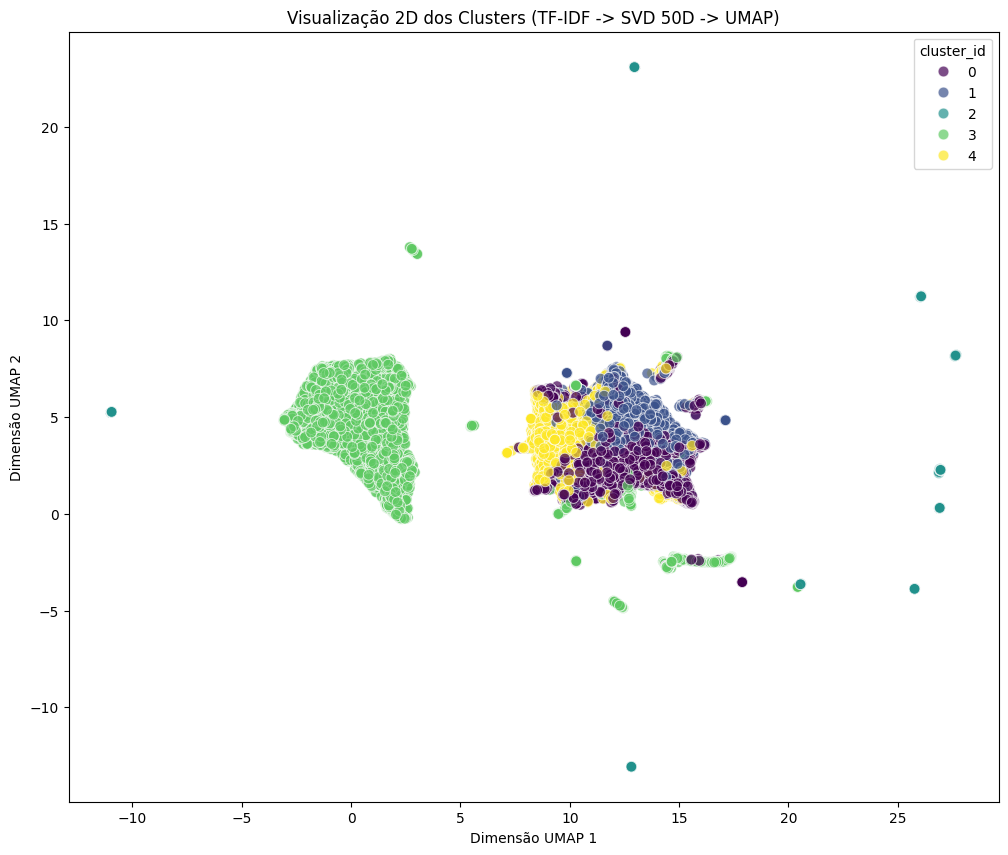

In [ ]:
import umap

matriz_tfidf = pipeline.named_steps['tfidfvectorizer'].transform(df_musicas['letra'])
matriz_50d = pipeline.named_steps['truncatedsvd'].transform(matriz_tfidf)

redutor_umap = umap.UMAP(n_components=2, random_state=42)
coords_2d = redutor_umap.fit_transform(matriz_50d)

df_musicas['x_coord'] = coords_2d[:, 0]
df_musicas['y_coord'] = coords_2d[:, 1]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='x_coord',
    y='y_coord',
    hue='cluster_id',
    palette='viridis',
    data=df_musicas,
    legend='full',
    alpha=0.7,
    s=60
)

plt.title('Visualização 2D dos Clusters (TF-IDF -> SVD 50D -> UMAP)')
plt.xlabel('Dimensão UMAP 1')
plt.ylabel('Dimensão UMAP 2')
plt.show()